In [25]:
from numpy import argmax
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import r2_score
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
import pandas as pd

In [27]:
import numpy as np

df = pd.read_csv("All_external_test_Sets.csv")
df

,smiles_r,human_CL_mL_min_kg,human_VDss_L_kg,human_fup,human_thalf
0,C/[NH+]=C1/C[NH+](O)C(c2ccccc2)=c2cc(Cl)ccc2=N1,0.37,0.25,NaN,NaN
1,C1=C/COCc2cc(ccc2OCC[NH+]2CCCC2)Nc2nccc(n2)-c2...,0.58,3.82,0.01,27.7
2,C=C/C=C/C[C@@H](C)[C@@H](O)C1C(=O)NC(CC)C(=O)[...,17.67,35.90,0.03,30.0
3,C=C1CC[C@]2(O)[C@@H]3Cc4ccc([O-])c5c4[C@]2(CC[...,14.40,NaN,NaN,NaN
4,C=C1C[C@@H]2C(CC[C@]3(C)C(=O)CC[C@@H]23)[C@]2(...,145.00,NaN,NaN,NaN
...,...,...,...,...,...
310,[O-]c1ccc(CC[NH2+]CCCCCC[NH2+]CCc2ccccc2)cc1[O-],36.00,NaN,NaN,NaN
311,[O-]c1ccc2c(c1)C13CCCC[C@@]1(O)[C@H](C2)[NH+](...,40.00,NaN,NaN,NaN
312,[O-]c1ccc2c3c1O[C@@H]1[C@@H](O)CC[C@]4(O)[C@H]...,29.70,NaN,NaN,NaN
313,[O-]c1ncnc2[n-]ncc12,9.90,NaN,NaN,NaN


In [4]:
#df = df[df["source"]!="Lombardo"].reset_index(drop=True)
#df

In [5]:
df.describe()

,human_CL_mL_min_kg,human_VDss_L_kg,human_fup,human_thalf
count,302.000000,51.000000,34.000000,38.000000
mean,10.938526,5.344346,0.179706,22.167895
std,24.259069,10.921131,0.260227,26.925397
min,0.050000,0.090000,0.010000,0.040000
25%,1.740000,0.295000,0.012500,3.602500
50%,4.165000,0.940000,0.045000,12.500000
75%,10.507500,3.670000,0.260000,31.500000
max,240.000000,58.480000,0.980000,111.000000


In [6]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import inchi
from rdkit.Chem.MolStandardize import rdMolStandardize
import pickle
from mordred import Calculator, descriptors
from rdkit.Chem.rdMolDescriptors import GetMorganFingerprintAsBitVect
from sklearn.feature_selection import VarianceThreshold
from itertools import compress

from dimorphite_dl.dimorphite_dl import DimorphiteDL
from rdkit.Chem import AddHs
from rdkit.Chem.MolStandardize import rdMolStandardize

def standardize(smiles):
    # follows the steps in
    # https://github.com/greglandrum/RSC_OpenScience_Standardization_202104/blob/main/MolStandardize%20pieces.ipynb
    # as described **excellently** (by Greg) in
    # https://www.youtube.com/watch?v=eWTApNX8dJQ
    try: 
        mol = Chem.MolFromSmiles(smiles)
        #print(smiles)
        
        # removeHs, disconnect metal atoms, normalize the molecule, reionize the molecule
        clean_mol = rdMolStandardize.Cleanup(mol) 
        #print(Chem.MolToSmiles(clean_mol))
        
        # if many fragments, get the "parent" (the actual mol we are interested in) 
        parent_clean_mol = rdMolStandardize.FragmentParent(clean_mol)

        # try to neutralize molecule
        uncharger = rdMolStandardize.Uncharger() # annoying, but necessary as no convenience method exists
        uncharged_parent_clean_mol = uncharger.uncharge(parent_clean_mol)

        #print(uncharged_parent_clean_mol)
        
        # use pH 7.4 https://git.durrantlab.pitt.edu/jdurrant/dimorphite_dl/
        dimorphite = DimorphiteDL(min_ph=7.4, max_ph=7.4, pka_precision=0)
        protonated_smiles = dimorphite.protonate(Chem.MolToSmiles(uncharged_parent_clean_mol))

        #print("protonated_smiles")
        
        if len(protonated_smiles) > 0:
                protonated_smile = protonated_smiles[0]

        protonated_mol = Chem.MolFromSmiles(protonated_smile)
        #protonated_mol= AddHs(protonated_mol)
        #protonated_smile = Chem.MolToSmiles(protonated_mol)


        # attempt is made at reionization at this step
        # at 7.4 pH

        te = rdMolStandardize.TautomerEnumerator() # idem
        taut_uncharged_parent_clean_mol = te.Canonicalize(protonated_mol)
     
        return  Chem.MolToSmiles(taut_uncharged_parent_clean_mol)
    
    except: 
        
        return "Cannot_do"

    
def calcdesc(data):
    # create descriptor calculator with all descriptors
    calc = Calculator(descriptors, ignore_3D=True)

    #print(len(calc.descriptors))
    Ser_Mol = data['smiles_r'].apply(Chem.MolFromSmiles)
    Mordred_table=  calc.pandas(Ser_Mol)
    Mordred_table = Mordred_table.astype('float')
    Mordred_table['smiles_r'] = data['smiles_r']
    
    Morgan_fingerprint= Ser_Mol.apply(GetMorganFingerprintAsBitVect, args=(2, 2048))
    Morganfingerprint_array  = np.stack(Morgan_fingerprint)

    Morgan_collection  = []
    for x in np.arange(Morganfingerprint_array.shape[1]): #np.arange plus rapide que range
        x = "Mfp"+str(x)
        Morgan_collection.append(x)

    Morganfingerprint_table  = pd.DataFrame(Morganfingerprint_array , columns=Morgan_collection )
    Morganfingerprint_table['smiles_r'] = data['smiles_r']
    
    data_mfp = pd.merge(data, Morganfingerprint_table)
    data_mfp_Mordred = pd.merge(data_mfp, Mordred_table)
    
    return(data_mfp_Mordred)
    

def predict_individual_animal(data, endpoint, animal):#predict animal data
    
    #Read columns needed for rat data
    file = open(f"../features_mfp_mordred_columns_{animal}_model.txt", "r")
    file_lines = file.read()
    features = file_lines.split("\n")
    features = features[:-1]

    loaded_rf = pickle.load(open(f"../log_{endpoint}_model_FINAL.sav", 'rb'))

    X = data[features]
    y_pred =  loaded_rf.predict(X)   

    return(y_pred)

def predict_animal(data):
    
    endpoints = {"dog_VDss_L_kg","dog_CL_mL_min_kg","dog_fup"}

    for endpoint in endpoints:
        preds = predict_individual_animal(data, endpoint, "dog") 
        data[endpoint] = preds

    endpoints = {"monkey_VDss_L_kg","monkey_CL_mL_min_kg","monkey_fup"}

    for endpoint in endpoints:
        preds = predict_individual_animal(data, endpoint, "monkey") 
        data[endpoint] = preds
    
    endpoints = {"rat_VDss_L_kg","rat_CL_mL_min_kg","rat_fup"}

    for endpoint in endpoints:
        preds = predict_individual_animal(data, endpoint, "rat") 
        data[endpoint] = preds
    
    return(data)



def predict_VDss(data, features):#
    

    loaded_rf = pickle.load(open("../log_human_VDss_L_kg_WITHOUTanimaldata_artificial_model_FINAL.sav", 'rb'))

    X = data[features].values
    y_preds =  loaded_rf.predict(X)   

    return(y_preds)

def predict_CL(data, features):

    loaded_rf = pickle.load(open("../log_human_CL_mL_min_kg_WITHOUTanimaldata_artificial_model_FINAL.sav", 'rb'))

    X = data[features].values
    y_preds =  loaded_rf.predict(X)   

    return(y_preds)

def predict_fup(data, features):
    
    loaded_rf = pickle.load(open("../log_human_fup_WITHOUTanimaldata_artificial_model_FINAL.sav", 'rb'))

    X = data[features].values
    y_preds =  loaded_rf.predict(X)   

    return(y_preds)

def predict_MRT(data, features):
    
    

    loaded_rf = pickle.load(open("../log_human_mrt_WITHOUTanimaldata_artificial_model_FINAL.sav", 'rb'))

    X = data[features].values
    y_preds =  loaded_rf.predict(X)   

    return(y_preds)

def predict_thalf(data, features):
    
    loaded_rf = pickle.load(open("../log_human_thalf_WITHOUTanimaldata_artificial_model_FINAL.sav", 'rb'))

    X = data[features].values
    y_preds =  loaded_rf.predict(X)  
    return(y_preds)

In [7]:
from pandarallel import pandarallel
pandarallel.initialize()

df["smiles_r"] = df["smiles_r"].parallel_apply(standardize)

INFO: Pandarallel will run on 56 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [8]:
df.describe()

,human_CL_mL_min_kg,human_VDss_L_kg,human_fup,human_thalf
count,302.000000,51.000000,34.000000,38.000000
mean,10.938526,5.344346,0.179706,22.167895
std,24.259069,10.921131,0.260227,26.925397
min,0.050000,0.090000,0.010000,0.040000
25%,1.740000,0.295000,0.012500,3.602500
50%,4.165000,0.940000,0.045000,12.500000
75%,10.507500,3.670000,0.260000,31.500000
max,240.000000,58.480000,0.980000,111.000000


In [9]:
df

,smiles_r,human_CL_mL_min_kg,human_VDss_L_kg,human_fup,human_thalf
0,C/[NH+]=C1/C[NH+](O)C(c2ccccc2)=c2cc(Cl)ccc2=N1,0.37,0.25,NaN,NaN
1,C1=C/COCc2cc(ccc2OCC[NH+]2CCCC2)Nc2nccc(n2)-c2...,0.58,3.82,0.01,27.7
2,C=C/C=C/C[C@@H](C)[C@@H](O)C1C(=O)NC(CC)C(=O)[...,17.67,35.90,0.03,30.0
3,C=C1CC[C@]2(O)[C@@H]3Cc4ccc([O-])c5c4[C@]2(CC[...,14.40,NaN,NaN,NaN
4,C=C1C[C@@H]2C(CC[C@]3(C)C(=O)CC[C@@H]23)[C@]2(...,145.00,NaN,NaN,NaN
...,...,...,...,...,...
310,[O-]c1ccc(CC[NH2+]CCCCCC[NH2+]CCc2ccccc2)cc1[O-],36.00,NaN,NaN,NaN
311,[O-]c1ccc2c(c1)C13CCCC[C@@]1(O)[C@H](C2)[NH+](...,40.00,NaN,NaN,NaN
312,[O-]c1ccc2c3c1O[C@@H]1[C@@H](O)CC[C@]4(O)[C@H]...,29.70,NaN,NaN,NaN
313,[O-]c1ncnc2[n-]ncc12,9.90,NaN,NaN,NaN


In [10]:
def count(pred, true, min, max, endpoint):

    if(endpoint == "human_fup"):
        lst = [abs(a/b) for a, b in zip(pred, true)]
        #print(lst)

        newlist = [x for x in lst if min <= x <= max]
        #print(newlist)

        return (len(newlist)/len(lst)) *100
    
    else:
        lst = [abs(10**a/10**b) for a, b in zip(pred, true)]
        #print(lst)

        newlist = [x for x in lst if min <= x <= max]
        #print(newlist)

        return (len(newlist)/len(lst)) *100
    
    return

def calc_gmfe(pred, true, endpoint):
    
    if(endpoint == "human_fup"):
        
        lst = [abs(np.log10(a/b)) for a, b in zip(pred, true)]
        mean_abs= np.mean(lst)
        return (10**mean_abs)
    
    else: 
        lst = [abs(np.log10(10**a/10**b)) for a, b in zip(pred, true)]
        mean_abs= np.mean(lst)
        
        return (10** mean_abs)
    
    return
                         
def median_fold_change_error(pred, true, endpoint):
                         
    if (endpoint == "human_fup"):
        lst = [abs(np.log10(a/b)) for a, b in zip(pred, true)]
        median_abs= np.median(lst) 
        return (np.e**median_abs)
    
    else:
        lst = [abs(np.log10(10**a/10**b)) for a, b in zip(pred, true)]
        median_abs= np.median(lst) 
        return (np.e**median_abs)
    
    return
                          
def calc_bias(pred, true, endpoint):
                          
    if (endpoint == "human_fup"):
        lst = [(a - b) for a, b in zip(pred, true)]                 
        bias= np.median(lst)
        return bias
    
    else:
        lst = [(10**a - 10**b) for a, b in zip(pred, true)]                 
        bias= np.median(lst)
        return bias
    
    return

In [11]:
len(df)

315

In [12]:
#read from file features
file = open("../features_mfp_mordred_columns_human.txt", "r")
file_lines = file.read()
features_mfp_mordred_columns = file_lines.split("\n")
features_mfp_mordred_columns = features_mfp_mordred_columns[:-1]

In [13]:
features_mfp_mordred_columns

['nAcid',
 'nBase',
 'SpDiam_A',
 'VE1_A',
 'nBridgehead',
 'nS',
 'nP',
 'nF',
 'nX',
 'AATS0d',
 'AATS2d',
 'AATS3d',
 'AATS1s',
 'AATS1are',
 'AATS2are',
 'AATS3are',
 'AATS0p',
 'ATSC0c',
 'ATSC1c',
 'ATSC2c',
 'ATSC3c',
 'ATSC4c',
 'ATSC5c',
 'ATSC6c',
 'ATSC7c',
 'ATSC8c',
 'ATSC1se',
 'ATSC2se',
 'ATSC1pe',
 'ATSC3pe',
 'ATSC4pe',
 'ATSC5pe',
 'ATSC7pe',
 'ATSC8pe',
 'ATSC1p',
 'AATSC0dv',
 'AATSC1dv',
 'AATSC2dv',
 'AATSC3dv',
 'AATSC0s',
 'AATSC1s',
 'AATSC2s',
 'AATSC3s',
 'AATSC1v',
 'AATSC0i',
 'AATSC1i',
 'AATSC2i',
 'GATS1c',
 'GATS2c',
 'GATS2d',
 'GATS2se',
 'GATS1p',
 'GATS1i',
 'BCUTdv-1h',
 'BCUTdv-1l',
 'BCUTd-1h',
 'BCUTs-1h',
 'BCUTs-1l',
 'BCUTm-1l',
 'BCUTi-1l',
 'BalabanJ',
 'SM1_Dzm',
 'SM1_Dzi',
 'nBondsD',
 'nBondsT',
 'C2SP1',
 'C1SP2',
 'C3SP3',
 'C4SP3',
 'FCSP3',
 'Xch-6d',
 'Xch-7d',
 'Xch-6dv',
 'Xc-3d',
 'Xc-5d',
 'Xc-3dv',
 'Xc-5dv',
 'Xp-7dv',
 'NdsCH',
 'NdssC',
 'NaaaC',
 'NssssC',
 'NsNH3',
 'NssNH2',
 'NaaNH',
 'NsssNH',
 'NaaN',
 'NsssN',
 'NdO

In [14]:
data_mfp_Mordred = calcdesc(df)
data_mfp_Mordred

  1%|▍                                          | 3/315 [00:02<04:25,  1.18it/s]

/home/ss2686/miniconda3/envs/my-rdkit-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 17%|███████                                   | 53/315 [00:02<00:08, 29.73it/s]

/home/ss2686/miniconda3/envs/my-rdkit-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


 87%|███████████████████████████████████▋     | 274/315 [00:05<00:00, 96.19it/s]

/home/ss2686/miniconda3/envs/my-rdkit-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/ss2686/miniconda3/envs/my-rdkit-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|█████████████████████████████████████████| 315/315 [00:05<00:00, 56.07it/s]


,smiles_r,human_CL_mL_min_kg,human_VDss_L_kg,human_fup,human_thalf,Mfp0,Mfp1,Mfp2,Mfp3,Mfp4,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,C/[NH+]=C1/C[NH+](O)C(c2ccccc2)=c2cc(Cl)ccc2=N1,0.37,0.25,NaN,NaN,0,0,0,0,0,...,9.949751,63.023277,301.097093,8.137759,828.0,37.0,110.0,130.0,6.527778,4.694444
1,C1=C/COCc2cc(ccc2OCC[NH+]2CCCC2)Nc2nccc(n2)-c2...,0.58,3.82,0.01,27.7,0,0,0,0,0,...,10.236346,84.096047,473.254717,6.959628,3973.0,51.0,180.0,206.0,7.638889,7.805556
2,C=C/C=C/C[C@@H](C)[C@@H](O)C1C(=O)NC(CC)C(=O)[...,17.67,35.90,0.03,30.0,0,1,0,0,0,...,11.211996,126.438462,1220.892303,5.984766,38625.0,151.0,416.0,481.0,43.500000,19.416667
3,C=C1CC[C@]2(O)[C@@H]3Cc4ccc([O-])c5c4[C@]2(CC[...,14.40,NaN,NaN,NaN,0,0,0,0,0,...,10.930622,81.595235,339.183444,6.783669,1189.0,59.0,160.0,211.0,6.875000,5.034722
4,C=C1C[C@@H]2C(CC[C@]3(C)C(=O)CC[C@@H]23)[C@]2(...,145.00,NaN,NaN,NaN,0,0,0,0,0,...,10.596660,71.984835,296.177630,6.438644,892.0,47.0,132.0,168.0,7.902778,4.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310,[O-]c1ccc(CC[NH2+]CCCCCC[NH2+]CCc2ccccc2)cc1[O-],36.00,NaN,NaN,NaN,0,0,0,0,0,...,9.570459,59.431680,356.246378,6.142179,2557.0,30.0,118.0,127.0,7.444444,6.111111
311,[O-]c1ccc2c(c1)C13CCCC[C@@]1(O)[C@H](C2)[NH+](...,40.00,NaN,NaN,NaN,0,0,0,0,0,...,10.752719,60.334421,327.219829,6.173959,1145.0,50.0,144.0,183.0,6.291667,4.993056
312,[O-]c1ccc2c3c1O[C@@H]1[C@@H](O)CC[C@]4(O)[C@H]...,29.70,NaN,NaN,NaN,0,0,0,0,0,...,10.962024,77.785047,357.194008,6.739510,1356.0,60.0,164.0,215.0,7.125000,5.284722
313,[O-]c1ncnc2[n-]ncc12,9.90,NaN,NaN,NaN,0,0,0,0,0,...,9.161465,53.745115,134.023958,11.168663,105.0,12.0,52.0,61.0,2.833333,2.222222


In [15]:
data_mfp_Mordred

,smiles_r,human_CL_mL_min_kg,human_VDss_L_kg,human_fup,human_thalf,Mfp0,Mfp1,Mfp2,Mfp3,Mfp4,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,C/[NH+]=C1/C[NH+](O)C(c2ccccc2)=c2cc(Cl)ccc2=N1,0.37,0.25,NaN,NaN,0,0,0,0,0,...,9.949751,63.023277,301.097093,8.137759,828.0,37.0,110.0,130.0,6.527778,4.694444
1,C1=C/COCc2cc(ccc2OCC[NH+]2CCCC2)Nc2nccc(n2)-c2...,0.58,3.82,0.01,27.7,0,0,0,0,0,...,10.236346,84.096047,473.254717,6.959628,3973.0,51.0,180.0,206.0,7.638889,7.805556
2,C=C/C=C/C[C@@H](C)[C@@H](O)C1C(=O)NC(CC)C(=O)[...,17.67,35.90,0.03,30.0,0,1,0,0,0,...,11.211996,126.438462,1220.892303,5.984766,38625.0,151.0,416.0,481.0,43.500000,19.416667
3,C=C1CC[C@]2(O)[C@@H]3Cc4ccc([O-])c5c4[C@]2(CC[...,14.40,NaN,NaN,NaN,0,0,0,0,0,...,10.930622,81.595235,339.183444,6.783669,1189.0,59.0,160.0,211.0,6.875000,5.034722
4,C=C1C[C@@H]2C(CC[C@]3(C)C(=O)CC[C@@H]23)[C@]2(...,145.00,NaN,NaN,NaN,0,0,0,0,0,...,10.596660,71.984835,296.177630,6.438644,892.0,47.0,132.0,168.0,7.902778,4.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310,[O-]c1ccc(CC[NH2+]CCCCCC[NH2+]CCc2ccccc2)cc1[O-],36.00,NaN,NaN,NaN,0,0,0,0,0,...,9.570459,59.431680,356.246378,6.142179,2557.0,30.0,118.0,127.0,7.444444,6.111111
311,[O-]c1ccc2c(c1)C13CCCC[C@@]1(O)[C@H](C2)[NH+](...,40.00,NaN,NaN,NaN,0,0,0,0,0,...,10.752719,60.334421,327.219829,6.173959,1145.0,50.0,144.0,183.0,6.291667,4.993056
312,[O-]c1ccc2c3c1O[C@@H]1[C@@H](O)CC[C@]4(O)[C@H]...,29.70,NaN,NaN,NaN,0,0,0,0,0,...,10.962024,77.785047,357.194008,6.739510,1356.0,60.0,164.0,215.0,7.125000,5.284722
313,[O-]c1ncnc2[n-]ncc12,9.90,NaN,NaN,NaN,0,0,0,0,0,...,9.161465,53.745115,134.023958,11.168663,105.0,12.0,52.0,61.0,2.833333,2.222222


In [16]:
data_for_pred = data_mfp_Mordred

#data_for_pred = data_for_pred.dropna(subset=["Clearance_(CL)"]).reset_index(drop=True)
#data_for_pred = data_for_pred.dropna(subset=["Volume_of_distribution_(VDss)"]).reset_index(drop=True)
data_for_pred 

,smiles_r,human_CL_mL_min_kg,human_VDss_L_kg,human_fup,human_thalf,Mfp0,Mfp1,Mfp2,Mfp3,Mfp4,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,C/[NH+]=C1/C[NH+](O)C(c2ccccc2)=c2cc(Cl)ccc2=N1,0.37,0.25,NaN,NaN,0,0,0,0,0,...,9.949751,63.023277,301.097093,8.137759,828.0,37.0,110.0,130.0,6.527778,4.694444
1,C1=C/COCc2cc(ccc2OCC[NH+]2CCCC2)Nc2nccc(n2)-c2...,0.58,3.82,0.01,27.7,0,0,0,0,0,...,10.236346,84.096047,473.254717,6.959628,3973.0,51.0,180.0,206.0,7.638889,7.805556
2,C=C/C=C/C[C@@H](C)[C@@H](O)C1C(=O)NC(CC)C(=O)[...,17.67,35.90,0.03,30.0,0,1,0,0,0,...,11.211996,126.438462,1220.892303,5.984766,38625.0,151.0,416.0,481.0,43.500000,19.416667
3,C=C1CC[C@]2(O)[C@@H]3Cc4ccc([O-])c5c4[C@]2(CC[...,14.40,NaN,NaN,NaN,0,0,0,0,0,...,10.930622,81.595235,339.183444,6.783669,1189.0,59.0,160.0,211.0,6.875000,5.034722
4,C=C1C[C@@H]2C(CC[C@]3(C)C(=O)CC[C@@H]23)[C@]2(...,145.00,NaN,NaN,NaN,0,0,0,0,0,...,10.596660,71.984835,296.177630,6.438644,892.0,47.0,132.0,168.0,7.902778,4.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310,[O-]c1ccc(CC[NH2+]CCCCCC[NH2+]CCc2ccccc2)cc1[O-],36.00,NaN,NaN,NaN,0,0,0,0,0,...,9.570459,59.431680,356.246378,6.142179,2557.0,30.0,118.0,127.0,7.444444,6.111111
311,[O-]c1ccc2c(c1)C13CCCC[C@@]1(O)[C@H](C2)[NH+](...,40.00,NaN,NaN,NaN,0,0,0,0,0,...,10.752719,60.334421,327.219829,6.173959,1145.0,50.0,144.0,183.0,6.291667,4.993056
312,[O-]c1ccc2c3c1O[C@@H]1[C@@H](O)CC[C@]4(O)[C@H]...,29.70,NaN,NaN,NaN,0,0,0,0,0,...,10.962024,77.785047,357.194008,6.739510,1356.0,60.0,164.0,215.0,7.125000,5.284722
313,[O-]c1ncnc2[n-]ncc12,9.90,NaN,NaN,NaN,0,0,0,0,0,...,9.161465,53.745115,134.023958,11.168663,105.0,12.0,52.0,61.0,2.833333,2.222222


In [17]:
#WITHOUT ANIMAL
 
features = ["smiles_r"] + features_mfp_mordred_columns
data_mfp_Mordred_withoutanimal = data_for_pred[features]


CL = predict_CL(data_mfp_Mordred_withoutanimal, features_mfp_mordred_columns)       
Vd = predict_VDss(data_mfp_Mordred_withoutanimal, features_mfp_mordred_columns)   
fup = predict_fup(data_mfp_Mordred_withoutanimal, features_mfp_mordred_columns)   
MRT = predict_MRT(data_mfp_Mordred_withoutanimal, features_mfp_mordred_columns)   
thalf = predict_thalf(data_mfp_Mordred_withoutanimal, features_mfp_mordred_columns)   
   
preds= pd.DataFrame()
preds["smiles_r"] = data_for_pred["smiles_r"]
preds["human_VDss_L_kg"]= Vd
preds["human_CL_mL_min_kg"]= CL
preds["human_fup"]= fup
preds["human_thalf"]= thalf
preds["human_MRT"]= MRT



In [18]:
preds.to_csv("05e_AllExt_test_Performance_Metrics_withoutanimal_predictions.csv")
preds

,smiles_r,human_VDss_L_kg,human_CL_mL_min_kg,human_fup,human_thalf,human_MRT
0,C/[NH+]=C1/C[NH+](O)C(c2ccccc2)=c2cc(Cl)ccc2=N1,0.027443,0.162347,0.107827,0.957666,1.052504
1,C1=C/COCc2cc(ccc2OCC[NH+]2CCCC2)Nc2nccc(n2)-c2...,0.461630,0.859537,0.211132,0.914283,0.850897
2,C=C/C=C/C[C@@H](C)[C@@H](O)C1C(=O)NC(CC)C(=O)[...,0.064470,0.330015,0.491761,0.828860,0.608126
3,C=C1CC[C@]2(O)[C@@H]3Cc4ccc([O-])c5c4[C@]2(CC[...,0.840356,1.195442,0.648643,0.765709,0.808808
4,C=C1C[C@@H]2C(CC[C@]3(C)C(=O)CC[C@@H]23)[C@]2(...,0.084437,0.515598,0.109235,0.746291,0.697321
...,...,...,...,...,...,...
310,[O-]c1ccc(CC[NH2+]CCCCCC[NH2+]CCc2ccccc2)cc1[O-],0.448848,1.327420,0.336553,0.538701,0.386400
311,[O-]c1ccc2c(c1)C13CCCC[C@@]1(O)[C@H](C2)[NH+](...,1.012746,1.500749,0.177265,0.692080,0.724175
312,[O-]c1ccc2c3c1O[C@@H]1[C@@H](O)CC[C@]4(O)[C@H]...,0.661894,1.315374,0.506190,0.576226,0.560907
313,[O-]c1ncnc2[n-]ncc12,-0.141160,0.909426,0.889402,-0.001576,0.016677


In [19]:
test = df
test.describe()


,human_CL_mL_min_kg,human_VDss_L_kg,human_fup,human_thalf
count,302.000000,51.000000,34.000000,38.000000
mean,10.938526,5.344346,0.179706,22.167895
std,24.259069,10.921131,0.260227,26.925397
min,0.050000,0.090000,0.010000,0.040000
25%,1.740000,0.295000,0.012500,3.602500
50%,4.165000,0.940000,0.045000,12.500000
75%,10.507500,3.670000,0.260000,31.500000
max,240.000000,58.480000,0.980000,111.000000


In [20]:
test

,smiles_r,human_CL_mL_min_kg,human_VDss_L_kg,human_fup,human_thalf
0,C/[NH+]=C1/C[NH+](O)C(c2ccccc2)=c2cc(Cl)ccc2=N1,0.37,0.25,NaN,NaN
1,C1=C/COCc2cc(ccc2OCC[NH+]2CCCC2)Nc2nccc(n2)-c2...,0.58,3.82,0.01,27.7
2,C=C/C=C/C[C@@H](C)[C@@H](O)C1C(=O)NC(CC)C(=O)[...,17.67,35.90,0.03,30.0
3,C=C1CC[C@]2(O)[C@@H]3Cc4ccc([O-])c5c4[C@]2(CC[...,14.40,NaN,NaN,NaN
4,C=C1C[C@@H]2C(CC[C@]3(C)C(=O)CC[C@@H]23)[C@]2(...,145.00,NaN,NaN,NaN
...,...,...,...,...,...
310,[O-]c1ccc(CC[NH2+]CCCCCC[NH2+]CCc2ccccc2)cc1[O-],36.00,NaN,NaN,NaN
311,[O-]c1ccc2c(c1)C13CCCC[C@@]1(O)[C@H](C2)[NH+](...,40.00,NaN,NaN,NaN
312,[O-]c1ccc2c3c1O[C@@H]1[C@@H](O)CC[C@]4(O)[C@H]...,29.70,NaN,NaN,NaN
313,[O-]c1ncnc2[n-]ncc12,9.90,NaN,NaN,NaN


In [21]:
test["human_CL_mL_min_kg"] = np.log10(test["human_CL_mL_min_kg"])
test["human_VDss_L_kg"] = np.log10(test["human_VDss_L_kg"])
test["human_fup"] = test["human_fup"]
test["human_thalf"] = np.log10(test["human_thalf"])
test = test.replace(np.inf, np.nan)
test = test.replace(-np.inf, np.nan)
test

,smiles_r,human_CL_mL_min_kg,human_VDss_L_kg,human_fup,human_thalf
0,C/[NH+]=C1/C[NH+](O)C(c2ccccc2)=c2cc(Cl)ccc2=N1,-0.431798,-0.602060,NaN,NaN
1,C1=C/COCc2cc(ccc2OCC[NH+]2CCCC2)Nc2nccc(n2)-c2...,-0.236572,0.582063,0.01,1.442480
2,C=C/C=C/C[C@@H](C)[C@@H](O)C1C(=O)NC(CC)C(=O)[...,1.247237,1.555094,0.03,1.477121
3,C=C1CC[C@]2(O)[C@@H]3Cc4ccc([O-])c5c4[C@]2(CC[...,1.158362,NaN,NaN,NaN
4,C=C1C[C@@H]2C(CC[C@]3(C)C(=O)CC[C@@H]23)[C@]2(...,2.161368,NaN,NaN,NaN
...,...,...,...,...,...
310,[O-]c1ccc(CC[NH2+]CCCCCC[NH2+]CCc2ccccc2)cc1[O-],1.556303,NaN,NaN,NaN
311,[O-]c1ccc2c(c1)C13CCCC[C@@]1(O)[C@H](C2)[NH+](...,1.602060,NaN,NaN,NaN
312,[O-]c1ccc2c3c1O[C@@H]1[C@@H](O)CC[C@]4(O)[C@H]...,1.472756,NaN,NaN,NaN
313,[O-]c1ncnc2[n-]ncc12,0.995635,NaN,NaN,NaN


In [22]:
test.describe()

,human_CL_mL_min_kg,human_VDss_L_kg,human_fup,human_thalf
count,302.000000,51.000000,34.000000,38.000000
mean,0.621912,0.117748,0.179706,0.968156
std,0.603989,0.720712,0.260227,0.714320
min,-1.301030,-1.045757,0.010000,-1.397940
25%,0.240528,-0.530240,0.012500,0.555762
50%,0.619615,-0.026872,0.045000,1.093760
75%,1.021251,0.564303,0.260000,1.498143
max,2.380211,1.767007,0.980000,2.045323


In [23]:
from sklearn.feature_selection import VarianceThreshold
from itertools import compress
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.metrics import r2_score


human_CL_mL_min_kg
(302,)
(302,)
2-fold :  66.55629139072848
3-fold :  78.80794701986756
5-fold :  86.75496688741721
gmfe :  1.9930285313270077
mfe :  1.1814186117610175
bias :  -0.015315303087239274
rmse  0.4505214605842107
r2  0.44177024673850684


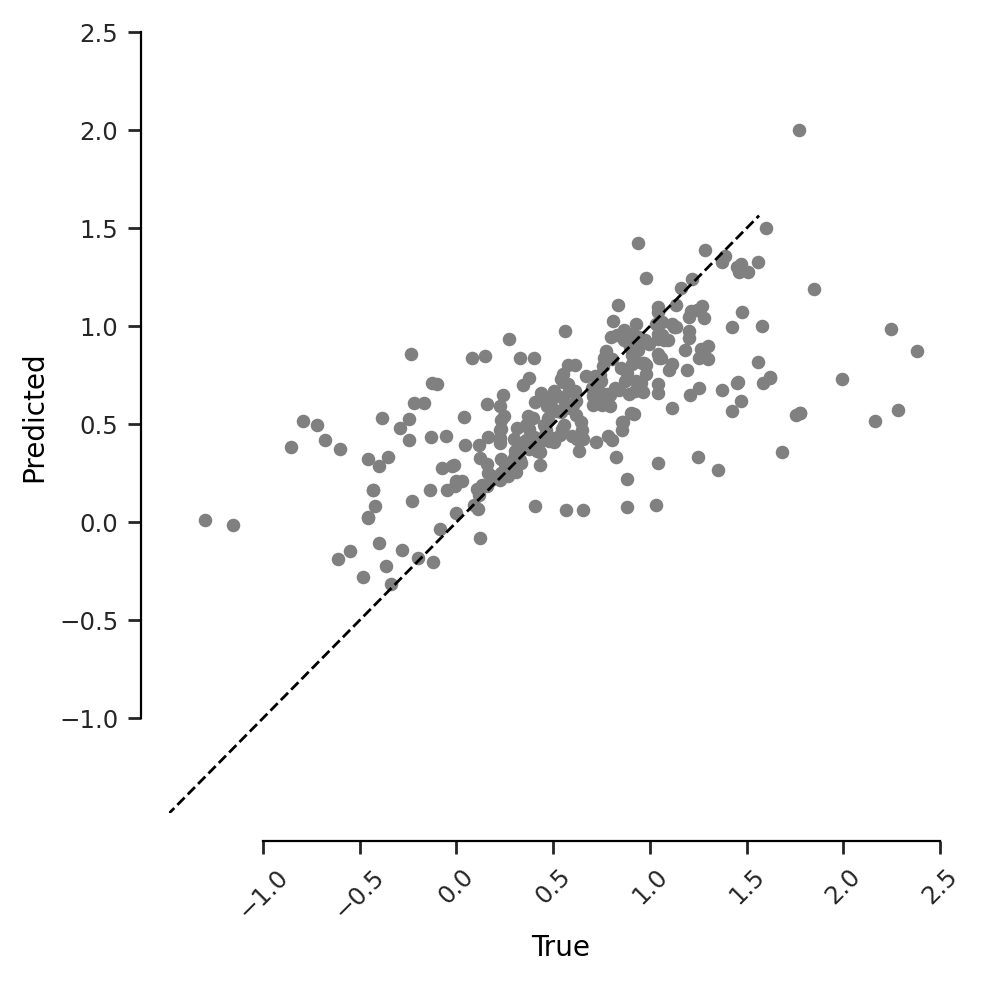

human_VDss_L_kg
(51,)
(51,)
2-fold :  45.09803921568628
3-fold :  68.62745098039215
5-fold :  84.31372549019608
gmfe :  2.5612563085046793
mfe :  1.367233061469059
bias :  -0.037496243824851505
rmse  0.5683253468374069
r2  0.3657343218852105


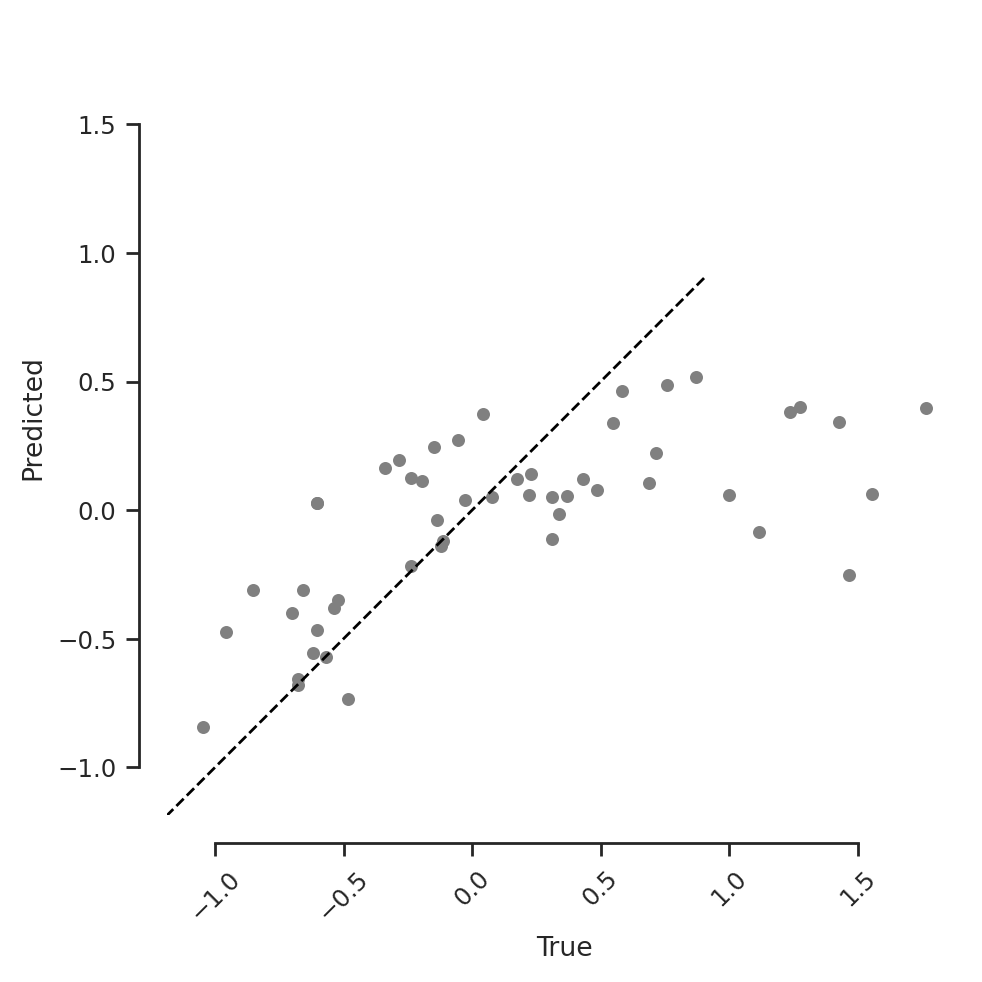

human_fup
(34,)
(34,)
2-fold :  17.647058823529413
3-fold :  41.17647058823529
5-fold :  55.88235294117647
gmfe :  4.684706683039778
mfe :  1.8486117878294885
bias :  0.08381664753075363
rmse  0.22702580168748818
r2  0.21582914759580796


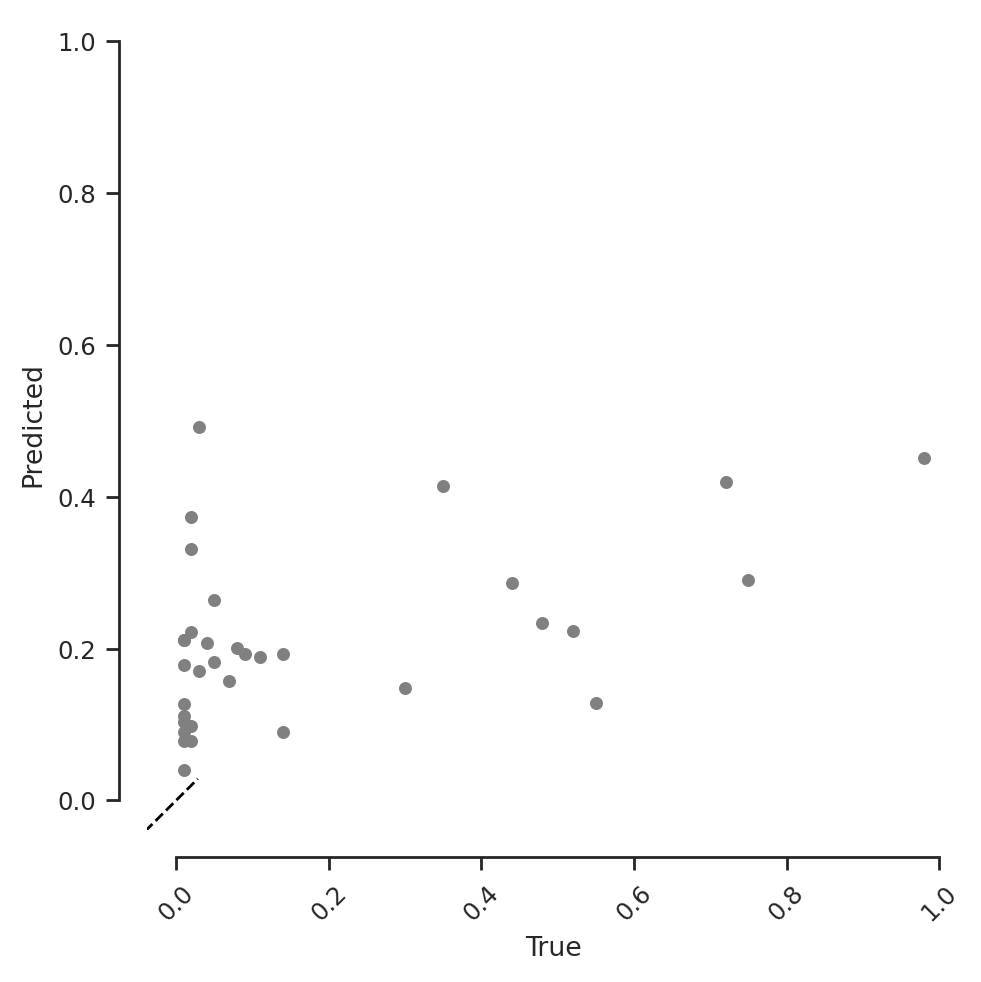

human_thalf
(38,)
(38,)
2-fold :  34.21052631578947
3-fold :  52.63157894736842
5-fold :  73.68421052631578
gmfe :  3.368337778967434
mfe :  1.5218659538837223
bias :  -4.494965858362818
rmse  0.6852172367441608
r2  0.05495364498790434


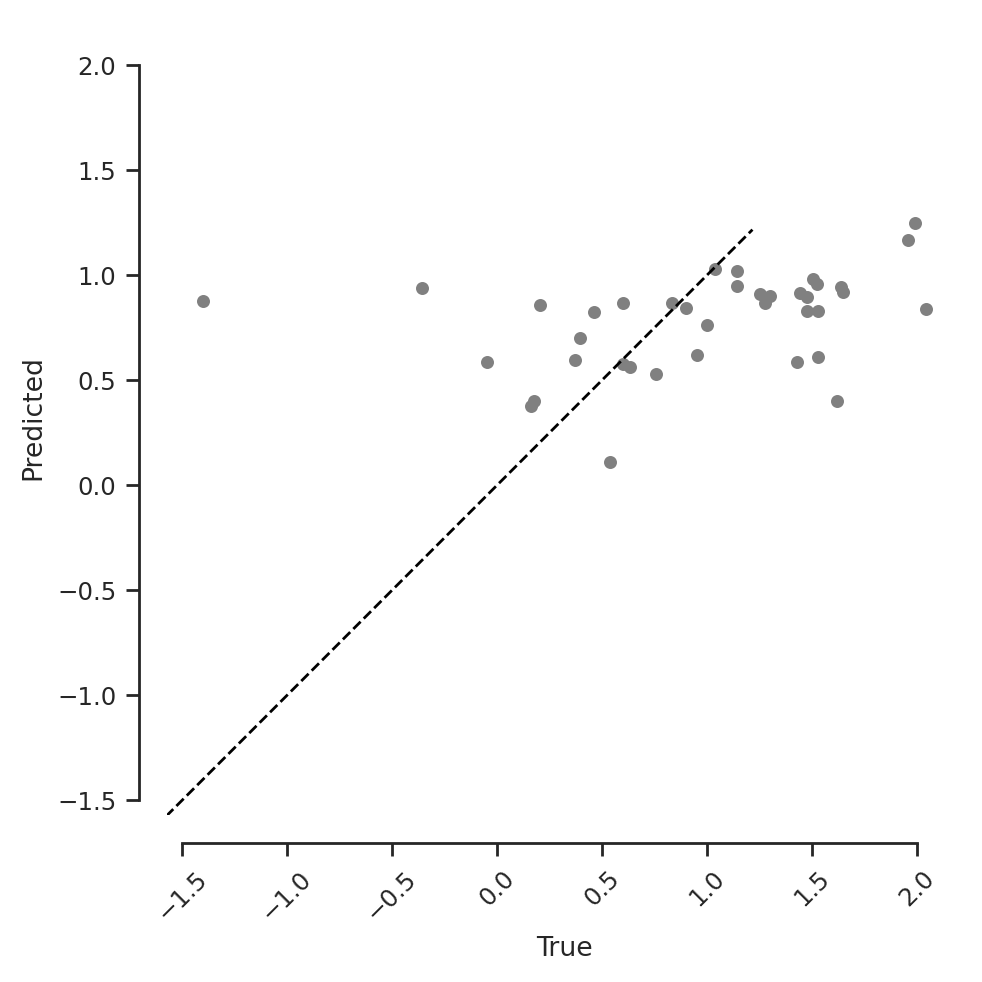

In [24]:
for endpoint in ["human_CL_mL_min_kg","human_VDss_L_kg","human_fup","human_thalf"]:
    
    print(endpoint)

    Y_test = df[[endpoint]].dropna().values.flatten()
    print(Y_test.shape)
    y_pred = preds[[endpoint]].iloc[df[[endpoint]].dropna().index].values.flatten()
    print(y_pred.shape)

    fold_2= count(y_pred, Y_test, 0.5, 2, endpoint)
    fold_3= count(y_pred, Y_test, 1/3, 3, endpoint)
    fold_5= count(y_pred, Y_test, 1/5, 5, endpoint)
    gmfe = calc_gmfe(y_pred, Y_test, endpoint)
    mfe = median_fold_change_error(y_pred, Y_test, endpoint)
    bias = calc_bias(y_pred, Y_test, endpoint)

    print("2-fold : ", fold_2)
    print("3-fold : ", fold_3)
    print("5-fold : ", fold_5)
    print("gmfe : ", gmfe)
    print("mfe : ", mfe)
    print("bias : ", bias)

    rmse = sqrt(mean_squared_error(Y_test, y_pred))
    print('rmse ',rmse)
    r2 = r2_score(Y_test, y_pred)
    print('r2 ',r2)

    
    fig = plt.figure(figsize =(5, 5), dpi=200) 

    plt.scatter(Y_test,  y_pred, color = 'gray', s=15) # s controls point size
    xleft, xright = plt.xlim()
    ybottom, ytop = plt.ylim()

    plt.xlim(min(xleft,ybottom) ,max(xright,ytop))
    plt.ylim(min(xleft,ybottom),max(xright,ytop))

    #add y=x line
    plt.plot([min(xleft,ybottom)-2,max(xright,ytop)-1],[min(xleft,ybottom)-2,max(xright,ytop)-1], lw=1, color='black', linestyle='dashed')

    sns.set_context("paper", font_scale=1)
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title("")

    sns.set_style('ticks')
    sns.despine(offset=10, trim=True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

